# Neural Network Implementation from Scratch
### T.Y. Tech — Generative AI Lab | Department of CSE (AIML)

**Name of Student:** Vishal Shende 

**PRN Number:** 202401110034 

**Class:** T.Y. Tech — Generative AI Lab  

**Batch:** A2  



## 1. Objective

In this assignment, I built a small neural network from scratch using only NumPy — no TensorFlow, PyTorch, or Keras. The goal was to actually understand how a neural network works under the hood, by writing the forward pass, backpropagation, and gradient descent myself instead of letting a library do it.


## 2. Problem Definition

**Dataset:** EMNIST Letters — this is basically like MNIST, but instead of digits (0-9) it has handwritten letters (A-Z). Each image is 28x28 pixels and grayscale.

**Task:** Given one of these images, the network has to predict which letter it is. This is a classification problem with 26 possible classes.


## 3. Loading the Dataset

I used the `emnist` package to download the dataset. This needs an internet connection the first time it runs, since it has to download the files.


In [8]:
!pip install emnist --quiet
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [6]:
!pip install torchvision --quiet

import numpy as np
import torchvision

# download EMNIST letters via torchvision (downloads from NIST directly, more reliable)
train_data = torchvision.datasets.EMNIST(root='./data', split='letters', train=True, download=True)
test_data = torchvision.datasets.EMNIST(root='./data', split='letters', train=False, download=True)

X_train_img = train_data.data.numpy()
y_train_raw = train_data.targets.numpy()

X_test_img = test_data.data.numpy()
y_test_raw = test_data.targets.numpy()

print("Train images:", X_train_img.shape)
print("Test images:", X_test_img.shape)

100%|██████████| 562M/562M [00:06<00:00, 83.6MB/s]


Train images: (124800, 28, 28)
Test images: (20800, 28, 28)


## 4. Preparing the Data

Before feeding images into the network, I had to clean them up a bit:

- Each image is a 28x28 grid, but the network needs a flat list of numbers, so I reshape it into 784 values.
- Pixel values go from 0 to 255, so I divide by 255 to bring everything into the 0-1 range. This makes training more stable.
- The labels from EMNIST are numbered 1-26, so I shift them to 0-25 to match normal array indexing.
- I also convert the labels into one-hot vectors, since that's the format the output layer expects.
- Finally, I only use a smaller chunk of the full dataset, just so training doesn't take forever.


In [26]:
# using a smaller sample so this trains reasonably fast
train_samples = 5000
test_samples = 1000

X_train = X_train_img[:train_samples].reshape(train_samples, 28 * 28) / 255.0
X_test = X_test_img[:test_samples].reshape(test_samples, 28 * 28) / 255.0

# EMNIST labels start at 1, shifting them so 'A' = 0, 'B' = 1, ... 'Z' = 25
y_train = y_train_raw[:train_samples] - 1
y_test = y_test_raw[:test_samples] - 1

num_classes = 26

# turns a label like 2 into [0, 0, 1, 0, 0, ..., 0]
def one_hot(labels, num_classes):
    encoded = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        encoded[i][label] = 1
    return encoded

Y_train = one_hot(y_train, num_classes)
Y_test = one_hot(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)


X_train shape: (5000, 784)
Y_train shape: (5000, 26)


Just to make sure everything loaded correctly, here are a few sample images with their labels:


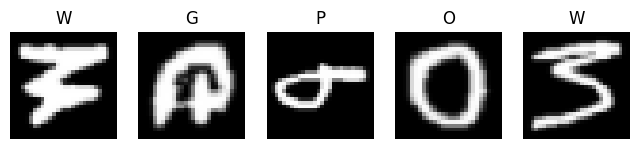

In [27]:
letters = [chr(ord('A') + i) for i in range(26)]

plt.figure(figsize=(8, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(letters[y_train[i]])
    plt.axis('off')
plt.show()


## 5. Methodology

**Architecture** — I kept it simple, just one hidden layer:

| Layer | Size | Activation |
|---|---|---|
| Input | 784 (pixels) | - |
| Hidden | 64 | ReLU |
| Output | 26 (letters) | Softmax |

**How data moves through the network (forward pass):**
- First, multiply the input by the first set of weights and add the bias: `Z1 = X.W1 + b1`
- Pass that through ReLU: `A1 = ReLU(Z1)`
- Multiply by the second set of weights and add bias again: `Z2 = A1.W2 + b2`
- Turn that into probabilities using softmax: `A2 = Softmax(Z2)`

**Loss function:** I used Cross-Entropy Loss, since that's the standard choice for classification problems like this one.

**Backpropagation:** this is how the network learns — it looks at how wrong the prediction was, then works backward through the layers to figure out how much each individual weight contributed to that error.

**Optimization:** once I know how "wrong" each weight is, I nudge it slightly in the direction that reduces the error. This is just gradient descent — repeat this enough times and the network gets better.


## 6. Activation and Loss Functions

Since I can't use any library functions for these, I wrote them myself.


In [28]:
def relu(z):
    # ReLU just turns any negative number into 0, and leaves positive numbers as they are
    return np.maximum(0, z)

def relu_derivative(z):
    # slope of ReLU: 1 if the input was positive, 0 otherwise
    return (z > 0).astype(float)

def softmax(z):
    # turns raw scores into probabilities that add up to 1
    z = z - np.max(z, axis=1, keepdims=True)  # subtracting the max avoids huge numbers blowing up
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    # tells us how far off our predicted probabilities are from the actual answer
    n = y_true.shape[0]
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)  # stops log(0) from happening
    return -np.sum(y_true * np.log(y_pred)) / n


## 7. Setting Up the Network

Before training starts, the weights need some initial values. I used small random numbers for the weights (so all the neurons don't start out identical) and zeros for the biases.


In [29]:
input_size = 784
hidden_size = 64
output_size = 26
learning_rate = 0.5

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))


## 8. Forward Pass

This function just runs the data through the network one time and returns the prediction, along with the in-between values (I need those later for backpropagation).


In [30]:
def forward_pass(X, W1, b1, W2, b2):
    Z1 = X.dot(W1) + b1
    A1 = relu(Z1)
    Z2 = A1.dot(W2) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


## 9. Backpropagation

This is the part that figures out how to adjust each weight. It starts at the output and works backward, using the chain rule at each step.


In [31]:
def backward_pass(X, Y, Z1, A1, A2, W2):
    n = X.shape[0]

    # how wrong the output layer was
    dZ2 = A2 - Y
    dW2 = A1.T.dot(dZ2) / n
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n

    # pass that error back to the hidden layer
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T.dot(dZ1) / n
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n

    return dW1, db1, dW2, db2


## 10. Training the Network

Now I just repeat the same process over and over: make a prediction, check how wrong it was, figure out the gradients, then update the weights a little bit. Doing this many times is what actually trains the network.


In [32]:
epochs = 300
loss_history = []

for epoch in range(epochs):
    # step 1: make a prediction
    Z1, A1, Z2, A2 = forward_pass(X_train, W1, b1, W2, b2)

    # step 2: check how wrong it was
    loss = cross_entropy_loss(Y_train, A2)
    loss_history.append(loss)

    # step 3: figure out how to fix the weights
    dW1, db1, dW2, db2 = backward_pass(X_train, Y_train, Z1, A1, A2, W2)

    # step 4: actually update the weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # print progress every so often so I can see it's actually learning
    if epoch % 30 == 0:
        predictions = np.argmax(A2, axis=1)
        true_labels = np.argmax(Y_train, axis=1)
        accuracy = np.mean(predictions == true_labels)
        print(f"Epoch {epoch}: Loss = {loss:.4f}, Train Accuracy = {accuracy*100:.2f}%")


Epoch 0: Loss = 3.2580, Train Accuracy = 4.12%
Epoch 30: Loss = 2.4716, Train Accuracy = 36.02%
Epoch 60: Loss = 1.7011, Train Accuracy = 50.78%
Epoch 90: Loss = 1.3029, Train Accuracy = 61.90%
Epoch 120: Loss = 1.1160, Train Accuracy = 67.46%
Epoch 150: Loss = 1.0078, Train Accuracy = 71.20%
Epoch 180: Loss = 0.9138, Train Accuracy = 73.30%
Epoch 210: Loss = 0.8232, Train Accuracy = 75.92%
Epoch 240: Loss = 0.7465, Train Accuracy = 78.56%
Epoch 270: Loss = 0.6986, Train Accuracy = 79.48%


## 11. Results

### 11.1 Loss Curve

If training is going well, this should trend downward over time.


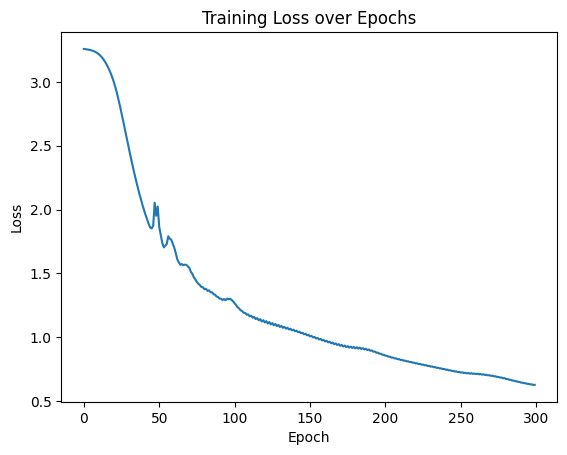

In [33]:
plt.plot(loss_history)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


### 11.2 Accuracy on Test Data

This is the real test — data the network hasn't seen during training.


In [34]:
_, _, _, A2_test = forward_pass(X_test, W1, b1, W2, b2)
test_predictions = np.argmax(A2_test, axis=1)
test_true_labels = np.argmax(Y_test, axis=1)
test_accuracy = np.mean(test_predictions == test_true_labels)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Accuracy: 74.50%


### 11.3 A Few Example Predictions

Just to see the network's predictions next to the real answers.


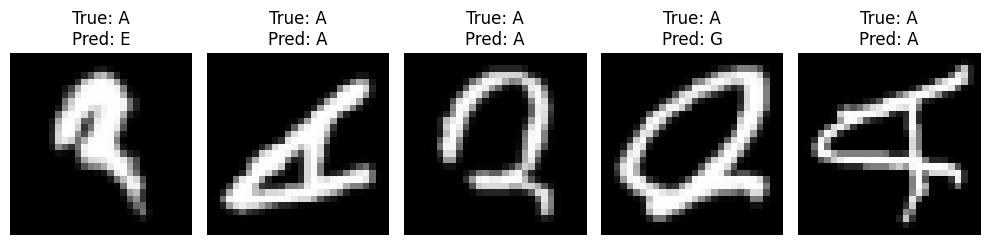

In [37]:
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    true_letter = letters[test_true_labels[i]]
    pred_letter = letters[test_predictions[i]]
    plt.title(f"True: {true_letter}\nPred: {pred_letter}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 12. Conclusion

I built a simple neural network (784 → 64 → 26) completely from scratch, without using any deep learning library. The whole process came down to four steps repeated again and again: make a guess, measure how wrong it is, figure out which direction to adjust the weights, and then make a small update in that direction. After training for a few hundred epochs, the network got noticeably better at recognizing letters, which shows that the forward pass and backpropagation were implemented correctly.

If I wanted to improve this further, I could try adding a second hidden layer, training on more data, or using a better optimizer like Adam instead of plain gradient descent.